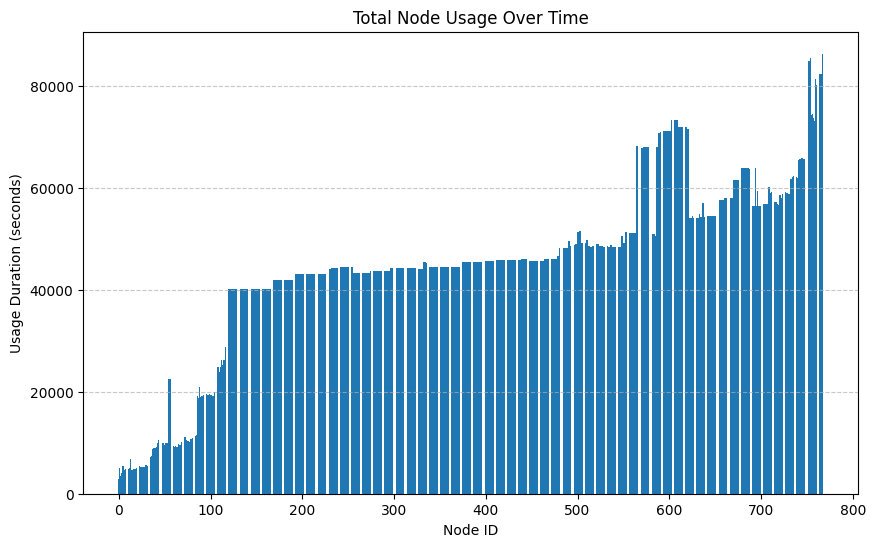

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import ast

def plot_node_usage(csv_path):
    # Load CSV
    df = pd.read_csv(csv_path)

    # Ensure numeric timestamps
    df['START'] = pd.to_numeric(df['START'], errors='coerce')
    df['FINISH'] = pd.to_numeric(df['FINISH'], errors='coerce')

    # Compute duration (seconds)
    df['DURATION'] = df['FINISH'] - df['START']

    # Parse NODELIST (handle comma-separated or stringified lists)
    def parse_nodes(nodelist):
        if pd.isna(nodelist):
            return []
        try:
            if isinstance(nodelist, str):
                if nodelist.startswith('['):  # handle JSON-like
                    return ast.literal_eval(nodelist)
                elif ',' in nodelist:
                    return [int(n.strip()) for n in nodelist.split(',')]
                else:
                    return [int(nodelist.strip())]
            return [int(nodelist)]
        except Exception:
            return []

    df['NODELIST'] = df['NODELIST'].apply(parse_nodes)

    # Aggregate usage per node over time
    node_usage = {}
    for _, row in df.iterrows():
        for node in row['NODELIST']:
            node_usage[node] = node_usage.get(node, 0) + row['DURATION']

    # Convert to DataFrame
    usage_df = pd.DataFrame(list(node_usage.items()), columns=['Node', 'Total_Usage_s'])
    usage_df = usage_df.sort_values('Node')

    # Plot
    plt.figure(figsize=(10, 6))
    plt.bar(usage_df['Node'], usage_df['Total_Usage_s'])
    plt.title("Total Node Usage Over Time")
    plt.xlabel("Node ID")
    plt.ylabel("Usage Duration (seconds)")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

# Example usage:
plot_node_usage("job_transitions.csv")
